In [1]:
from PIL import Image
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import math

plt.style.use('dark_background')

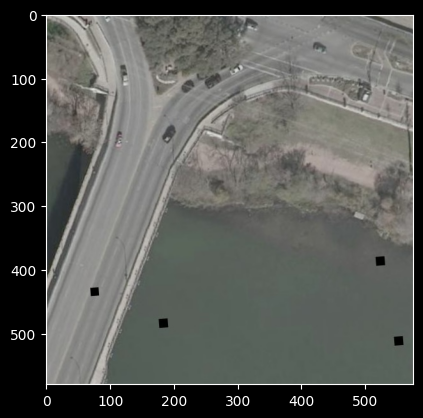

In [2]:
# plot original image
# load image and preprocess
original_png = Image.open("./original.jpg")
plt.imshow(original_png)

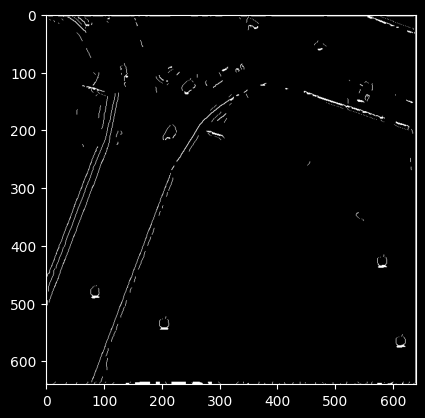

In [3]:
# input and plot image
# load image and preprocess
edges_image = Image.open("./edge_image.png")

transform1 = transforms.ToTensor()
transform2 = transforms.Resize((640, 640))

edges_image = transform2(transform1(edges_image))
edges_image = edges_image.view(640, 640)

plt.imshow(edges_image, cmap="grey", vmin=0, vmax=1)

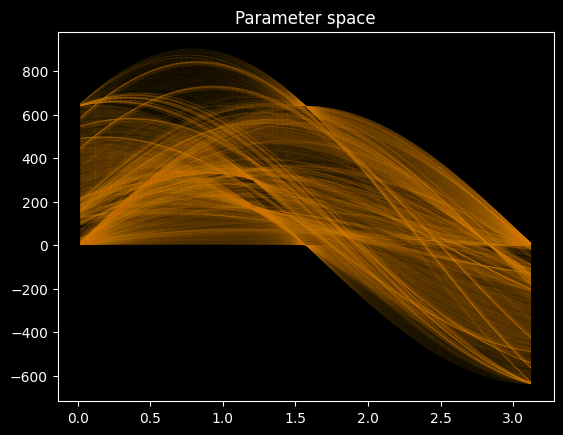

In [4]:
def hough_line_transformation(input_image, threshold = 150, th = 180):
    # create set of angles theta
    theta = torch.arange(torch.pi / th, torch.pi, torch.pi / th) 
    # get input dimensions of image
    H, W = input_image.shape
    # calculate diagonal of input image as good value for creating bins
    diag = math.sqrt( H **2 + W**2)
    # accumulation array
    acc = torch.linspace(start=0, end= int(diag), steps=int(diag) + 1)
    vote_matr = torch.zeros((acc.shape[0], theta.shape[0]))

    # iterate over image
    for i in range(H):
        for j in range(W):
            # looking only on edges
            if input_image[i,j] == 1:

                # to plot lines
                p_line = (i + 1) * torch.cos(theta) + (j + 1) * torch.sin(theta)
                plt.plot(theta, p_line, color='orange',linewidth=0.01)
                # look into each angle
                for th_idx in range(theta.shape[0]):
                    # p = x * cos(theta) + y * sin(theta)
                    p = (i + 1) * torch.cos(theta[th_idx]) + (j + 1) * torch.sin(theta[th_idx])
                    # vote and regarding bin position
                    if p > 0 and p < diag:
                        vote_matr[int(acc[int(p)]), th_idx] +=1

    
    plt.title("Parameter space")   
    plt.show()

    # prepare output image
    output_image = torch.zeros(input_image.shape)

    # iterate over voting matrix
    for rho_idx in range(vote_matr.shape[0]):
        for theta_idx in range(vote_matr.shape[1]): 
            # setting up custom threshold
            if vote_matr[rho_idx, theta_idx] > threshold:

                # create the lines from rho and theta
                theta_val = theta[theta_idx]
                rho_val = acc[rho_idx]
                # for each row pixel in image, finding y
                for x in range(output_image.shape[0]):

                    # y = ( - cos(theta) / sin(theta)) * x + rtho / sin(theta)
                    # to avoid nans, we work as non 0 first coordinates
                    y = (-torch.cos(theta_val) / torch.sin(theta_val)) * (x + 1) + (rho_val / torch.sin(theta_val))

                    # if y within image, then we plot point
                    if 0 <= int(y) < output_image.shape[1]:
                        output_image[int(x), int(y)] = 1
    
    return output_image

out_image = hough_line_transformation(input_image=edges_image, threshold=110)

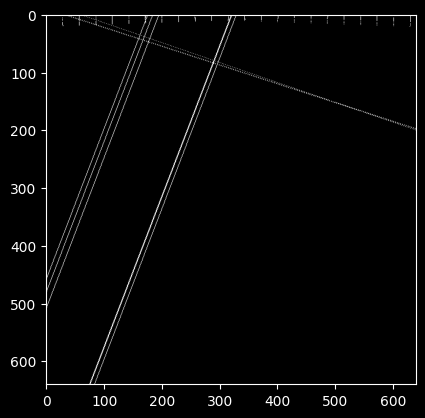

In [5]:
plt.imshow(out_image, cmap="grey", vmin=0, vmax=1)